In [16]:
from dataclasses import dataclass
import matplotlib.pyplot as plt

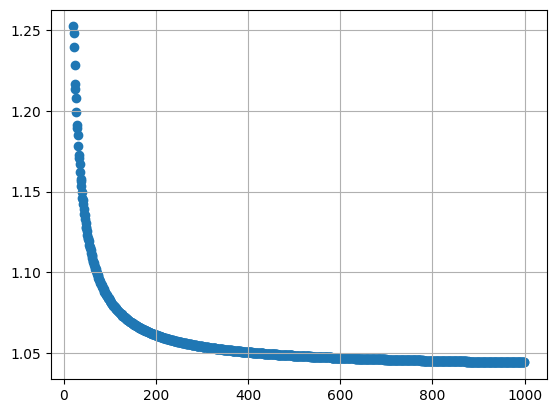

In [25]:
JUMP_VELOCITY = 0.42
# JUMP_VELOCITY = 0.0
DRAG = 0.98
GRAVITY = -0.08
SPEED_THRESHOLD = 0.005

@dataclass
class JumpResult:
    max_height: float
    return_to_start_s: float
    x: list[float]
    y: list[float]

def simulate_jump(tps, time_s):
    computed_jump_velocity = JUMP_VELOCITY * 20.0 / tps
    computed_drag = DRAG ** (20.0 / tps)
    computed_gravity = GRAVITY * 20.0 / tps * DRAG / computed_drag * (1 - computed_drag) / (1 - DRAG)
    computed_speed_threshold = SPEED_THRESHOLD * 20.0 / tps

    def init(start_position):
        velocity = computed_jump_velocity
        # No drag right after setting jump velocity
        # velocity *= DRAG
        start_position += velocity

        return start_position, velocity

    def iterate(position: float, velocity: float):
        velocity += computed_gravity
        velocity *= computed_drag
        position += velocity

        if abs(velocity) < computed_speed_threshold:
            velocity = 0.0

        return position, velocity

    counter = 0
    start_position = 0
    positions = [start_position]
    position, velocity = init(start_position)
    max_height = start_position
    return_to_start_s = None
    
    while counter < time_s * tps:
        position, velocity = iterate(position, velocity)
        counter += 1
        positions.append(position)
        max_height = max(position, max_height)
        if position <= start_position and return_to_start_s is None:
            return_to_start_s = counter / tps

    return JumpResult(max_height, return_to_start_s, [time / tps for time in range(0, counter + 1)], positions)

jmp_20 = simulate_jump(20, 0.55)
jmp_40 = simulate_jump(40, 0.55)
jmp_200 = simulate_jump(200, 0.55)


fig, ax = plt.subplots()
# ax.plot(jmp_20.x, jmp_20.y)
# ax.plot(jmp_40.x, jmp_40.y)
# ax.plot(jmp_200.x, jmp_200.y)
ax.scatter(range(20, 1000), [simulate_jump(float(tps), 0.55).max_height for tps in range(20, 1000)])
ax.grid()
plt.show()